## importing libraries

In [37]:
import os 
import matplotlib.pyplot as plt
import numpy as np
from src.kmeans import KMeans
from src.io_utils import load_points, scale_minmax, scale_zscore

In [38]:
# Create folder for saving graphs
output_folder = 'graphs'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Created '{output_folder}' folder")
else:
    print(f"'{output_folder}' folder exists")


Created 'graphs' folder


### Load data

In [39]:
points = load_points('data/sample.csv')
points = np.array(points)

print(f"Loaded {len(points)} points")
print(f"Data shape : {points.shape}")

Loaded 150 points
Data shape : (150, 2)


### Original data scatter plot

In [40]:
plt.style.use("seaborn-v0_8-darkgrid")

Saved : 1_original_data.png


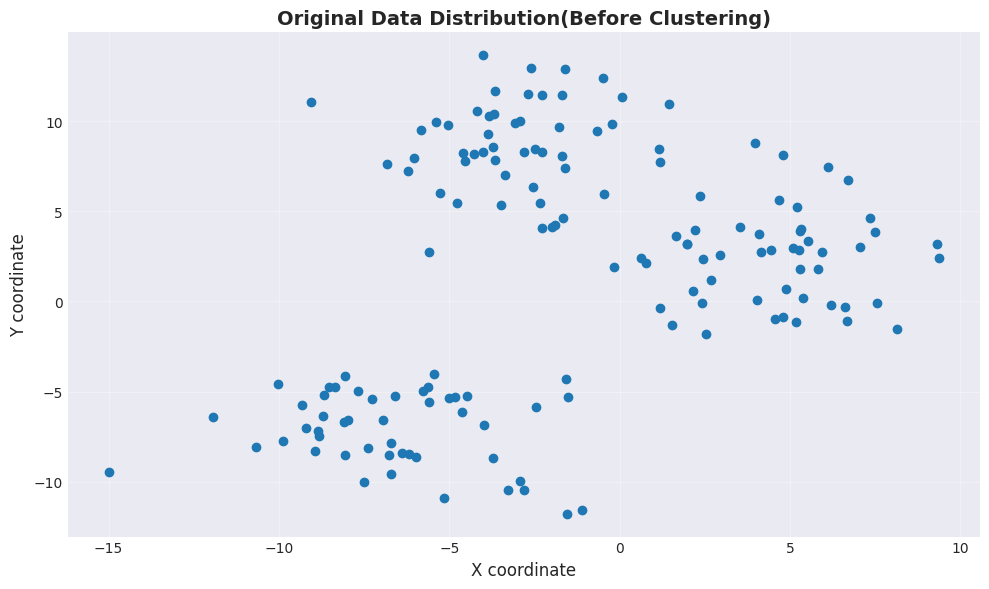

In [41]:
plt.figure(figsize=(10,6))
plt.scatter(points[:,0],points[:,1])
plt.title("Original Data Distribution(Before Clustering)", fontsize= 14, fontweight = "bold")
plt.xlabel("X coordinate",fontsize=12)
plt.ylabel("Y coordinate",fontsize=12)
plt.grid(True, alpha = 0.3)
plt.tight_layout()

#save figure
plt.savefig(f"{output_folder}/1_original_data.png",dpi = 300,bbox_inches = "tight")
print("Saved : 1_original_data.png")
plt.show()

## Graph 2 - clustered data : k=3

In [42]:
#run kmeans clustering
model = KMeans(K=3)
model.fit(points,n_init=10,init="kmeans++",verbose = False)

KMeans(K=3, max_iters=100)

Saved : 2_clustered_data_k3.png


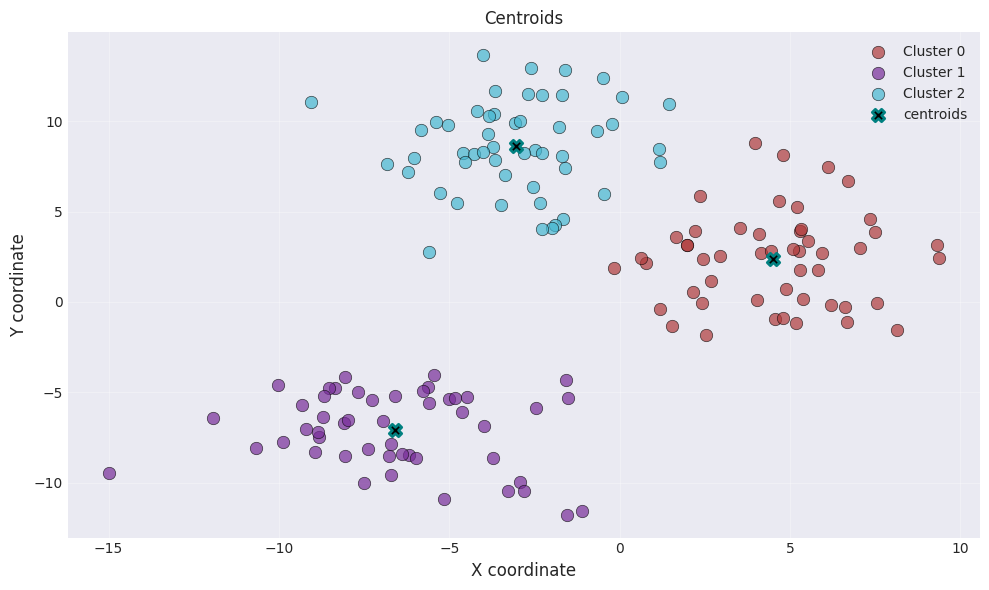


Clustering Results:
  SSE: 1718.1572
  Iterations: 4
  Cluster sizes: [50, 49, 51]


In [52]:
#fig 2 clustered data
colors = ["#AF3A3A","#772D99",'#45B7D1']
assignments = np.array(model.assignments)

plt.figure(figsize=(10,6))
for k in range(3):
    cluster_points = points[assignments == k]
    plt.scatter(cluster_points[:,0], cluster_points[:,1],
    c = colors[k], label = f"Cluster {k}" ,s= 80, alpha = 0.7, edgecolors = 'black', linewidths=0.5)

centroids = np.array(model.centroids)
# plt.figure(figsize=(6,6))
plt.scatter(centroids[:,0], centroids[:,1], marker="X",c = "black", s = 80, label = "centroids", zorder = 5, edgecolors = "teal", linewidth=2)
plt.title("Centroids")
plt.xlabel("X coordinate", fontsize =12)
plt.ylabel("Y coordinate", fontsize =12)
plt.grid(True, alpha = 0.3)
plt.legend(fontsize=10)
plt.tight_layout()
#save figure
plt.savefig(f"{output_folder}/2_clustered_data_k3.png",dpi = 300,bbox_inches = "tight")
print("Saved : 2_clustered_data_k3.png")
plt.show()

print(f"\nClustering Results:")
print(f"  SSE: {model.sse:.4f}")
print(f"  Iterations: {model.iterations}")
print(f"  Cluster sizes: {model.get_cluster_sizes()}")

### Figure 3: Elbow Method

Saved: 3_elbow_method.png


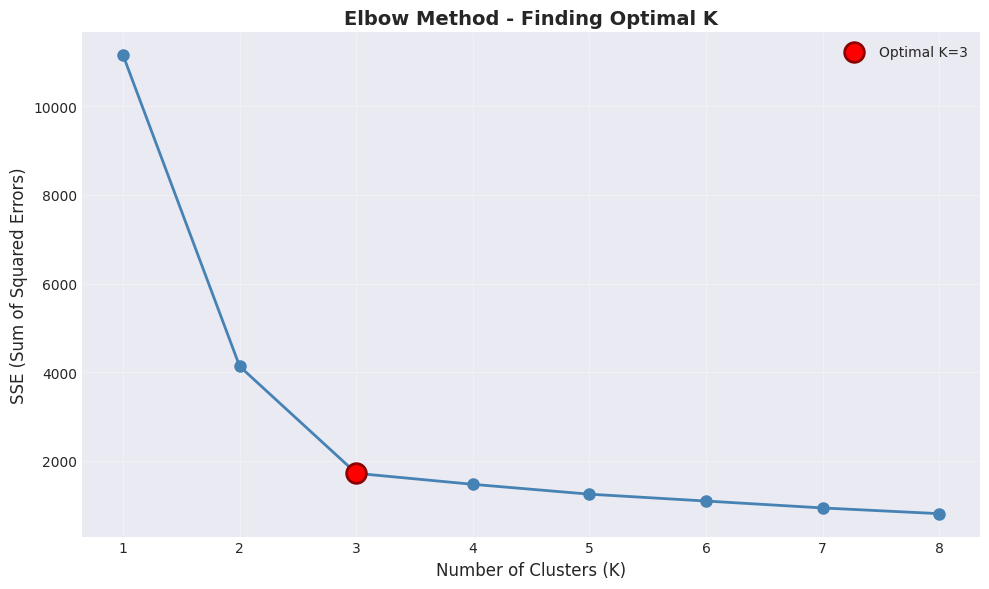


SSE for different K values:
  K=1: SSE=11149.4085
  K=2: SSE=4130.8896
  K=3: SSE=1718.1572 ← Optimal
  K=4: SSE=1469.4972
  K=5: SSE=1247.3223
  K=6: SSE=1092.5285
  K=7: SSE=936.9873
  K=8: SSE=807.7698


In [ ]:

results = KMeans.elbow_method(points, max_k=8, n_init=5, verbose=False)

plt.figure(figsize=(10, 6))
plt.plot(results.keys(), results.values(), marker='o', 
         color='steelblue', linewidth=2, markersize=8)

# Highlight the elbow point (K=3)
plt.scatter([3], [results[3]], color='red', s=200, zorder=5, 
            edgecolors='darkred', linewidth=2, label='Optimal K=3')

plt.title('Elbow Method - Finding Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('SSE (Sum of Squared Errors)', fontsize=12)
plt.xticks(range(1, 9))
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
plt.savefig(f'{output_folder}/3_elbow_method.png', dpi=300, bbox_inches='tight')
print("Saved: 3_elbow_method.png")
plt.show()

# Print SSE values
print("\nSSE for different K values:")
for k, sse in results.items():
    marker = " ← Optimal" if k == 3 else ""
    print(f"  K={k}: SSE={sse:.4f}{marker}")



 ### Random vs K-Means++ Comparison

/tmp/ipykernel_38475/1498435732.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(box_data, labels=['Random', 'K-Means++'],


✓ Saved: 4_random_vs_kmeans_plusplus.png


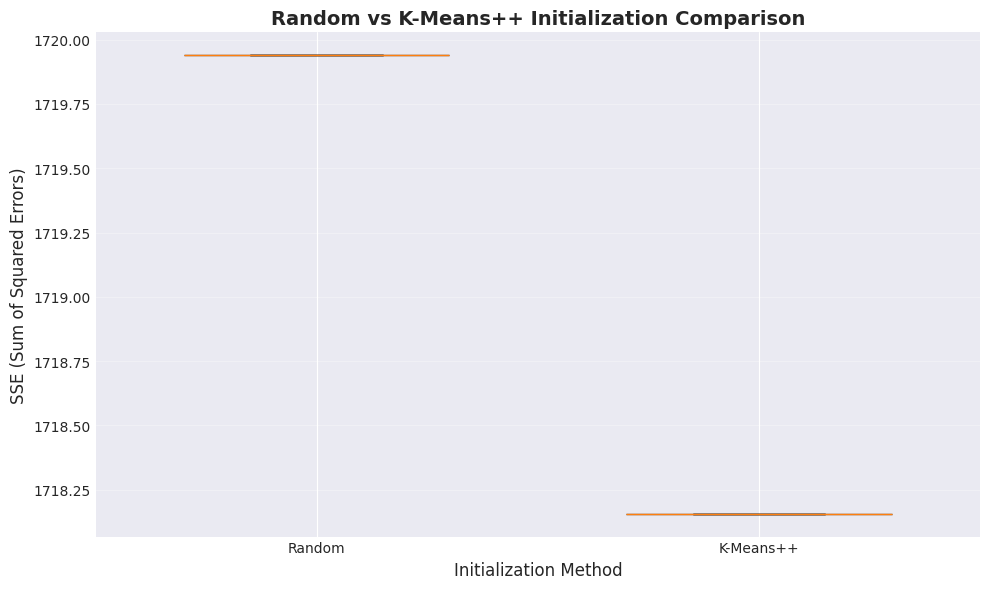


Comparison Statistics:
Random Init:
  Average SSE: 1719.9391
  Best SSE: 1719.9391
  Worst SSE: 1719.9391
  Std Dev: 0.0000

K-Means++ Init:
  Average SSE: 1718.1572
  Best SSE: 1718.1572
  Worst SSE: 1718.1572
  Std Dev: 0.0000


In [ ]:

n_runs = 10

# Random initialization
sse_random = []
for i in range(n_runs):
    model_r = KMeans(K=3)
    model_r.fit(points, n_init=1, init='random', verbose=False)
    sse_random.append(model_r.sse)

# K-Means++ initialization
sse_kmeans_pp = []
for i in range(n_runs):
    model_pp = KMeans(K=3)
    model_pp.fit(points, n_init=1, init='kmeans++', verbose=False)
    sse_kmeans_pp.append(model_pp.sse)

# Figure 4: Box plot comparison
plt.figure(figsize=(10, 6))
box_data = [sse_random, sse_kmeans_pp]
bp = plt.boxplot(box_data, labels=['Random', 'K-Means++'], 
                 patch_artist=True, widths=0.6)

# Color the boxes
colors = ['#FF6B6B', '#4ECDC4']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('Random vs K-Means++ Initialization Comparison', fontsize=14, fontweight='bold')
plt.ylabel('SSE (Sum of Squared Errors)', fontsize=12)
plt.xlabel('Initialization Method', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

# Save figure
plt.savefig(f'{output_folder}/4_random_vs_kmeans_plusplus.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 4_random_vs_kmeans_plusplus.png")
plt.show()

# Print statistics
print("\nComparison Statistics:")
print(f"Random Init:")
print(f"  Average SSE: {np.mean(sse_random):.4f}")
print(f"  Best SSE: {np.min(sse_random):.4f}")
print(f"  Worst SSE: {np.max(sse_random):.4f}")
print(f"  Std Dev: {np.std(sse_random):.4f}")

print(f"\nK-Means++ Init:")
print(f"  Average SSE: {np.mean(sse_kmeans_pp):.4f}")
print(f"  Best SSE: {np.min(sse_kmeans_pp):.4f}")
print(f"  Worst SSE: {np.max(sse_kmeans_pp):.4f}")
print(f"  Std Dev: {np.std(sse_kmeans_pp):.4f}")
# Cell 7: Graph 5 - Convergence Comparison

### Convergence Comparison (Iterations)

✓ Saved: 5_convergence_comparison.png


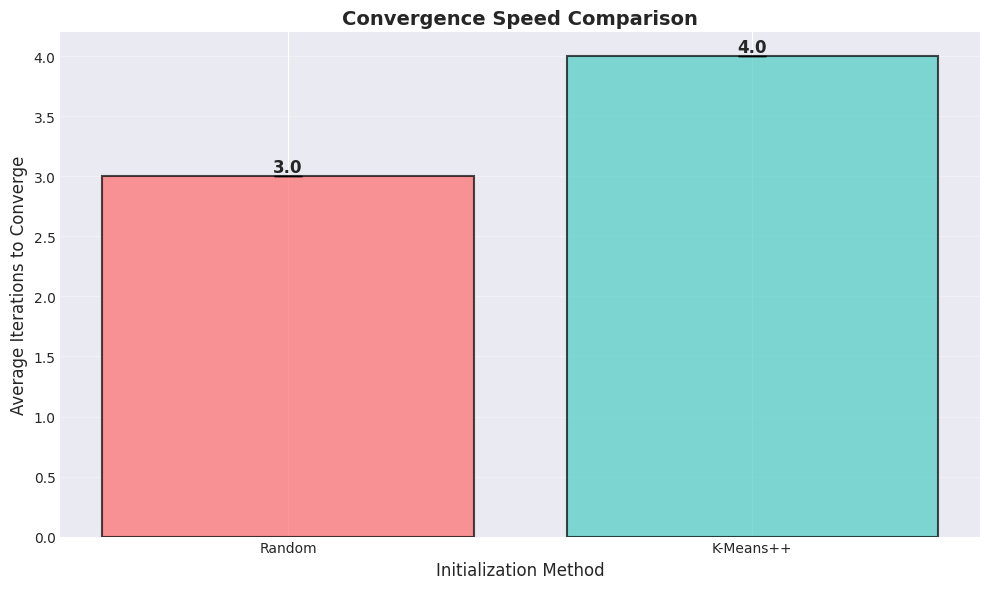


Average Iterations:
  Random: 3.00 ± 0.00
  K-Means++: 4.00 ± 0.00


In [ ]:

iterations_random = []
iterations_kmeans_pp = []

for i in range(n_runs):
    # Random
    model_r = KMeans(K=3)
    model_r.fit(points, n_init=1, init='random', verbose=False)
    iterations_random.append(model_r.iterations)
    
    # K-Means++
    model_pp = KMeans(K=3)
    model_pp.fit(points, n_init=1, init='kmeans++', verbose=False)
    iterations_kmeans_pp.append(model_pp.iterations)

# Figure 5: Bar chart comparison
plt.figure(figsize=(10, 6))
x_pos = np.arange(2)
means = [np.mean(iterations_random), np.mean(iterations_kmeans_pp)]
stds = [np.std(iterations_random), np.std(iterations_kmeans_pp)]

bars = plt.bar(x_pos, means, yerr=stds, capsize=10, alpha=0.7, 
               color=['#FF6B6B', '#4ECDC4'], edgecolor='black', linewidth=1.5)

plt.xticks(x_pos, ['Random', 'K-Means++'])
plt.ylabel('Average Iterations to Converge', fontsize=12)
plt.xlabel('Initialization Method', fontsize=12)
plt.title('Convergence Speed Comparison', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{means[i]:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()

# Save figure
plt.savefig(f'{output_folder}/5_convergence_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: 5_convergence_comparison.png")
plt.show()

print(f"\nAverage Iterations:")
print(f"  Random: {np.mean(iterations_random):.2f} ± {np.std(iterations_random):.2f}")
print(f"  K-Means++: {np.mean(iterations_kmeans_pp):.2f} ± {np.std(iterations_kmeans_pp):.2f}")